# HBV Constant Su_max Calibration (Cal/Val)

This notebook runs the constant-Su_max HBV model from hbv_bmi_constant.py with a multi-objective Monte Carlo calibration and calibration/validation split.

In [19]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from hbv_bmi_constant import HBV_Bmi

In [20]:
base = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
temp_path = base / 'ERA5_Temp_1980_2026.csv'
precip_path = base / 'Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv'
evap_path = base / 'Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv'
grdc_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')
shape_area = 28191724718  # m2

In [21]:
# Build monthly dataframe (1980-2020)
df_t = pd.read_csv(temp_path)
df_t['year'] = df_t['system:index'].astype(str).str[:4].astype(int)
df_t['month'] = df_t['system:index'].astype(str).str[4:6].astype(int)
df_t['temperature_C'] = df_t['temperature_2m'] - 273.15
temp_monthly = df_t.pivot_table(index='year', columns='month', values='temperature_C').loc[1980:2020]
temp_array = temp_monthly.values.flatten()

df_p = pd.read_csv(precip_path)
df_e = pd.read_csv(evap_path)
df_p = df_p[(df_p['system:index'] >= 198001) & (df_p['system:index'] <= 202012)].reset_index(drop=True)
df_e = df_e[(df_e['system:index'] >= 198001) & (df_e['system:index'] <= 202012)].reset_index(drop=True)

grdc = pd.read_csv(
    grdc_path,
    encoding='latin-1',
    sep=';',
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc.columns = ['q_m3s']
grdc['year'] = grdc.index.year
grdc['month'] = grdc.index.month
q_month = grdc.groupby(['year', 'month'])['q_m3s'].mean().reset_index()
q_month['Date'] = pd.to_datetime(q_month[['year', 'month']].assign(day=1))
q_month = q_month[(q_month['year'] >= 1980) & (q_month['year'] <= 2020)].sort_values('Date').reset_index(drop=True)

dates = pd.date_range('1980-01-01', '2020-12-01', freq='MS')
monthly_df = pd.DataFrame({
    'Date': dates,
    'precip_m_month': df_p['total_precipitation_sum'].values,
    'evap_m_month': df_e[df_e.columns[1]].values,
    'temperature_C': temp_array,
    'q_m3s': q_month['q_m3s'].values,
})
monthly_df['days_in_month'] = monthly_df['Date'].dt.days_in_month
monthly_df['precip_mm_month'] = monthly_df['precip_m_month'] * 1000.0
monthly_df['pet_mm_month'] = (-monthly_df['evap_m_month']).clip(lower=0) * 1000.0
monthly_df['precip_mm_day'] = monthly_df['precip_mm_month'] / monthly_df['days_in_month']
monthly_df['pet_mm_day'] = monthly_df['pet_mm_month'] / monthly_df['days_in_month']
monthly_df['q_obs_mm_day'] = monthly_df['q_m3s'] * 86400.0 / shape_area * 1000.0
monthly_df.head()

,Date,precip_m_month,evap_m_month,temperature_C,q_m3s,days_in_month,precip_mm_month,pet_mm_month,precip_mm_day,pet_mm_day,q_obs_mm_day
0,1980-01-01,0.077218,-0.006487,-1.001031,592.322581,31,77.218060,6.487182,2.490905,0.209264,1.815308
1,1980-02-01,0.081914,-0.021555,3.847232,896.241379,29,81.913982,21.554530,2.824620,0.743260,2.746737
2,1980-03-01,0.089754,-0.037676,4.629214,269.935484,31,89.754468,37.676348,2.895305,1.215366,0.827279
3,1980-04-01,0.060644,-0.064560,6.306908,293.433333,30,60.644102,64.560134,2.021470,2.152004,0.899294
4,1980-05-01,0.073371,-0.092885,10.861671,180.354839,31,73.371170,92.885477,2.366812,2.996306,0.552739


In [25]:
# Write forcing files for hbv_bmi_constant.py (file-based model interface)
# Use a writable temp directory and unique filenames to avoid permission/lock conflicts.
time_index = pd.DatetimeIndex(monthly_df['Date'].values)
pr = xr.Dataset({'pr': ('time', monthly_df['precip_mm_day'].to_numpy())}, coords={'time': time_index})
pet = xr.Dataset({'evspsblpot': ('time', monthly_df['pet_mm_day'].to_numpy())}, coords={'time': time_index})

run_dir = Path.home() / 'tmp_hbv_constant'
run_dir.mkdir(parents=True, exist_ok=True)
run_tag = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S_%f')

pr_path = run_dir / f'tmp_pr_constant_{run_tag}.nc'
pet_path = run_dir / f'tmp_pet_constant_{run_tag}.nc'
cfg_path = run_dir / f'tmp_hbv_constant_config_{run_tag}.json'

pr.to_netcdf(pr_path, mode='w')
pet.to_netcdf(pet_path, mode='w')

q_obs = monthly_df['q_obs_mm_day'].to_numpy()
years = time_index.year

print('Wrote forcing files:')
print(pr_path)
print(pet_path)

Wrote forcing files:
/Users/doriswong/tmp_hbv_constant/tmp_pr_constant_20260402_165427_066866.nc
/Users/doriswong/tmp_hbv_constant/tmp_pet_constant_20260402_165427_066866.nc


In [23]:
def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    den = np.sum((obs - np.mean(obs)) ** 2)
    if den <= 0:
        return np.nan
    return 1 - np.sum((obs - sim) ** 2) / den

def log_nse(obs, sim, eps=1e-6):
    obs = np.maximum(np.asarray(obs, dtype=float), eps)
    sim = np.maximum(np.asarray(sim, dtype=float), eps)
    return nse(np.log(obs), np.log(sim))

def rel_bias(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    s_obs = np.sum(obs)
    if s_obs == 0:
        return np.nan
    return (np.sum(sim) - s_obs) / s_obs

def combined_score(obs, sim, w_nse=0.45, w_lognse=0.35, w_bias=0.20):
    a = nse(obs, sim)
    b = log_nse(obs, sim)
    c = rel_bias(obs, sim)
    if not (np.isfinite(a) and np.isfinite(b) and np.isfinite(c)):
        return np.nan
    return w_nse * a + w_lognse * b - w_bias * abs(c)

In [26]:
# Parameter bounds for constant-Su_max model (8 params)
# Imax, Ce, Sumax, beta, Pmax, Tlag, Kf, Ks
ParMinn = np.array([0.0, 0.3, 80.0, 0.8, 0.01, 1.0, 0.01, 0.001])
ParMaxn = np.array([4.0, 1.2, 500.0, 2.8, 0.15, 6.0, 0.06, 0.03])

spinup_steps = 24
N = 600

all_runs = []
for _ in range(N):
    p = np.random.uniform(ParMinn, ParMaxn)
    cfg = {
        'precipitation_file': str(pr_path),
        'potential_evaporation_file': str(pet_path),
        'parameters': ','.join([f'{v:.10f}' for v in p]),
        'initial_storage': '0.0,100.0,20.0,30.0'
    }
    with open(cfg_path, 'w') as f:
        json.dump(cfg, f)

    m = HBV_Bmi()
    m.initialize(str(cfg_path))

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    obs_s = q_obs[spinup_steps:]
    sim_s = sim[spinup_steps:]
    years_s = years[spinup_steps:]

    c_mask = (years_s >= 1980) & (years_s <= 2005)
    v_mask = (years_s >= 2006) & (years_s <= 2020)

    s_cal = combined_score(obs_s[c_mask], sim_s[c_mask])
    s_val = combined_score(obs_s[v_mask], sim_s[v_mask])
    rb_cal = rel_bias(obs_s[c_mask], sim_s[c_mask])

    if np.isfinite(s_cal) and np.isfinite(rb_cal):
        all_runs.append({'score_cal': s_cal, 'score_val': s_val, 'rb_cal': rb_cal, 'params': p, 'sim': sim})

if not all_runs:
    raise RuntimeError('No stable runs were found. Check forcing/units.')

# Prefer lower-bias runs, but do not fail if none pass threshold.
runs = [r for r in all_runs if abs(r['rb_cal']) <= 1.0]
if not runs:
    runs = all_runs
    print('No runs met |rel_bias_cal| <= 1.0; using all stable runs instead.')

best = max(runs, key=lambda d: d['score_cal'])
best_params = best['params']
best_sim = best['sim']
print('Stable runs:', len(all_runs), '/', N)
print('Accepted runs for ranking:', len(runs))
print('Best cal score:', best['score_cal'])
print('Best val score:', best['score_val'])
print('Best cal rel_bias:', best['rb_cal'])
print('Best params:', best_params)

No runs met |rel_bias_cal| <= 1.0; using all stable runs instead.
Stable runs: 600 / 600
Accepted runs for ranking: 600
Best cal score: -49.1622487429607
Best val score: -37.38766509792856
Best cal rel_bias: 8.11802492630398
Best params: [1.60107068e+00 3.01922856e-01 4.66401290e+02 2.71475137e+00
 2.50321444e-02 2.11239231e+00 3.77619524e-02 1.36005013e-02]


In [10]:
# Diagnostics
obs_s = q_obs[spinup_steps:]
sim_s = best_sim[spinup_steps:]
years_s = years[spinup_steps:]
c_mask = (years_s >= 1980) & (years_s <= 2005)
v_mask = (years_s >= 2006) & (years_s <= 2020)

metrics = pd.DataFrame({
    'period': ['cal', 'val'],
    'NSE': [nse(obs_s[c_mask], sim_s[c_mask]), nse(obs_s[v_mask], sim_s[v_mask])],
    'logNSE': [log_nse(obs_s[c_mask], sim_s[c_mask]), log_nse(obs_s[v_mask], sim_s[v_mask])],
    'rel_bias': [rel_bias(obs_s[c_mask], sim_s[c_mask]), rel_bias(obs_s[v_mask], sim_s[v_mask])],
})
metrics

,period,NSE,logNSE,rel_bias
0,cal,-93.360924,-9.877509,8.054658
1,val,-147.693236,-11.190611,9.799219


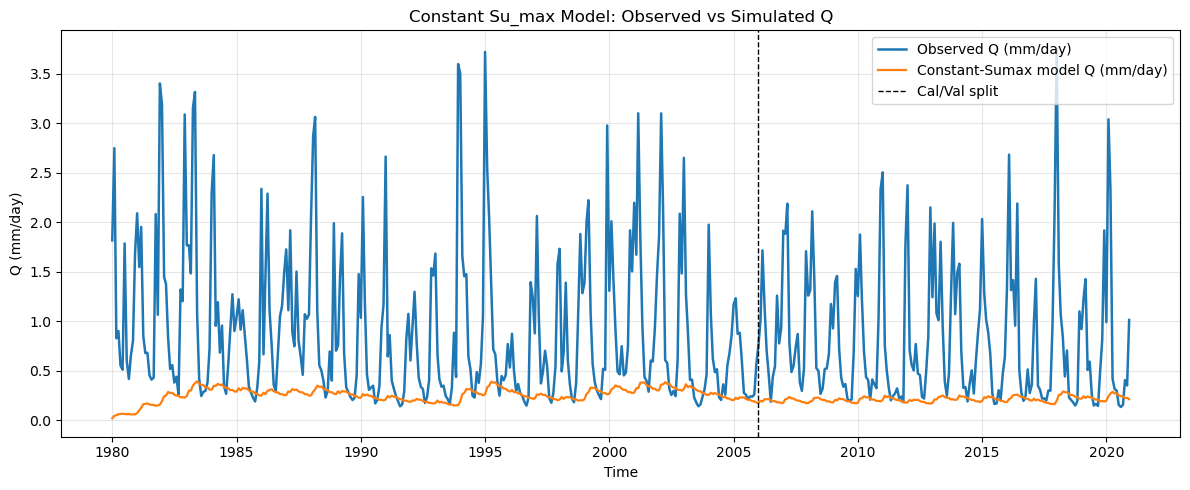

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time_index, q_obs, label='Observed Q (mm/day)', lw=1.8)
ax.plot(time_index, best_sim_mm_day, label='Constant-Sumax model Q (mm/day)', lw=1.6)
ax.axvline(pd.Timestamp('2006-01-01'), color='k', ls='--', lw=1, label='Cal/Val split')
ax.set_title('Constant Su_max Model: Observed vs Simulated Q')
ax.set_xlabel('Time')
ax.set_ylabel('Q (mm/day)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
# Tiny variability check for the full series
damping_table = pd.DataFrame({
    'series': ['observed', 'modeled_mm_day'],
    'min': [np.min(q_obs), np.min(best_sim_mm_day)],
    'max': [np.max(q_obs), np.max(best_sim_mm_day)],
    'std': [np.std(q_obs), np.std(best_sim_mm_day)],
})
damping_table

,series,min,max,std
0,observed,0.133069,3.749350,0.732496
1,modeled_mm_day,0.019468,0.393117,0.062911


In [12]:
result_df = pd.DataFrame({'time': time_index, 'q_obs_mm_day': q_obs, 'q_sim_mm_day': best_sim})
result_df.head()

,time,q_obs_mm_day,q_sim_mm_day
0,1980-01-01,1.815308,0.153426
1,1980-02-01,2.746737,0.665970
2,1980-03-01,0.827279,1.516420
3,1980-04-01,0.899294,2.218619
4,1980-05-01,0.552739,2.531519


## Apples-to-Apples Check Against Exercise 4 Logic

This section mirrors Exercise 4 choices as closely as possible in this workspace:
- Same HBV implementation family (constant `Su_max` model)
- Same parameter bounds from the exercise
- Same objective period (2011 only)
- NSE / logNSE objective focus

It also corrects a key unit mismatch by converting simulated monthly-step output to mm/day using days per month before computing NSE.

In [34]:
# Compare NSE with and without converting simulated output to mm/day
# HBV updates with timestep-integrated fluxes; for monthly timesteps, divide by days_in_month for mm/day comparison.
days = monthly_df['days_in_month'].to_numpy(dtype=float)
best_sim_mm_day = best_sim / days

mask_2010_2012 = (time_index >= pd.Timestamp('2010-01-01')) & (time_index <= pd.Timestamp('2012-12-31'))

comparison = pd.DataFrame({
    'metric': ['NSE_2010_2012', 'logNSE_2010_2012', 'rel_bias_2010_2012'],
    'raw_sim_vs_mmday_obs': [
        nse(q_obs[mask_2010_2012], best_sim[mask_2010_2012]),
        log_nse(q_obs[mask_2010_2012], best_sim[mask_2010_2012]),
        rel_bias(q_obs[mask_2010_2012], best_sim[mask_2010_2012]),
    ],
    'converted_sim_vs_mmday_obs': [
        nse(q_obs[mask_2010_2012], best_sim_mm_day[mask_2010_2012]),
        log_nse(q_obs[mask_2010_2012], best_sim_mm_day[mask_2010_2012]),
        rel_bias(q_obs[mask_2010_2012], best_sim_mm_day[mask_2010_2012]),
    ],
})
comparison

,metric,raw_sim_vs_mmday_obs,converted_sim_vs_mmday_obs
0,NSE_2010_2012,-63.964059,-0.709899
1,logNSE_2010_2012,-9.431678,-1.722390
2,rel_bias_2010_2012,7.015782,-0.736446


In [32]:
# Exercise-4-style Monte Carlo: same bounds and 2011 NSE objective
ParMinn_ex = np.array([0.0, 0.2, 40.0, 0.5, 0.001, 0.0, 0.01, 0.0001])
ParMaxn_ex = np.array([8.0, 1.0, 800.0, 4.0, 0.3, 10.0, 0.1, 0.01])

N_ex = 1000
results_ex = []

for _ in range(N_ex):
    p = np.random.uniform(ParMinn_ex, ParMaxn_ex)
    cfg = {
        'precipitation_file': str(pr_path),
        'potential_evaporation_file': str(pet_path),
        'parameters': ','.join([f'{v:.10f}' for v in p]),
        'initial_storage': '0.0,100.0,0.0,5.0',
    }
    with open(cfg_path, 'w') as f:
        json.dump(cfg, f)

    m = HBV_Bmi()
    m.initialize(str(cfg_path))

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_mm_day = sim / days

    nse_2011 = nse(q_obs[mask_2011], sim_mm_day[mask_2011])
    lognse_2011 = log_nse(q_obs[mask_2011], sim_mm_day[mask_2011])
    rb_2011 = rel_bias(q_obs[mask_2011], sim_mm_day[mask_2011])

    if np.isfinite(nse_2011) and np.isfinite(lognse_2011):
        results_ex.append({
            'params': p,
            'sim_mm_day': sim_mm_day,
            'nse_2011': nse_2011,
            'lognse_2011': lognse_2011,
            'rb_2011': rb_2011,
        })

if not results_ex:
    raise RuntimeError('No valid runs in exercise-style Monte Carlo.')

best_nse = max(results_ex, key=lambda d: d['nse_2011'])
best_lognse = max(results_ex, key=lambda d: d['lognse_2011'])

summary_ex = pd.DataFrame({
    'selection': ['best_by_nse', 'best_by_lognse'],
    'NSE_2011': [best_nse['nse_2011'], best_lognse['nse_2011']],
    'logNSE_2011': [best_nse['lognse_2011'], best_lognse['lognse_2011']],
    'rel_bias_2011': [best_nse['rb_2011'], best_lognse['rb_2011']],
})

print('Valid runs:', len(results_ex), '/', N_ex)# "Good" modelled vs observed plot using the best NSE run (exercise-style)
sim_good = best_nse['sim_mm_day']   # IMPORTANT: already converted to mm/day

Valid runs: 1000 / 1000


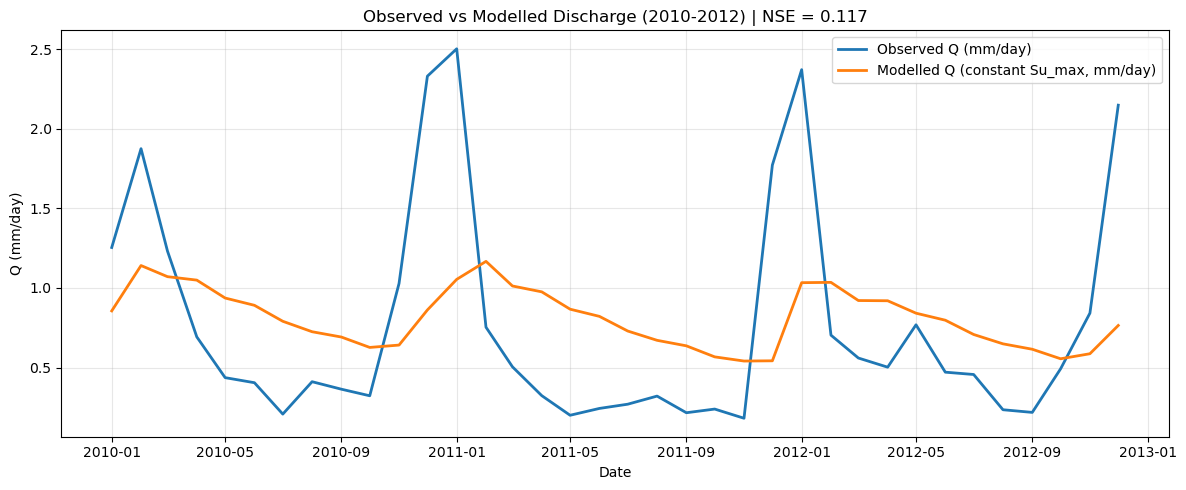

,selection,NSE_2011,logNSE_2011,rel_bias_2011
0,best_by_nse,0.168664,0.031001,-0.026606
1,best_by_lognse,0.065287,0.122273,-0.186281


In [37]:
# mask_2010_2012 = (time_index >= pd.Timestamp('2010-01-01')) & (time_index <= pd.Timestamp('2012-12-31'))
obs_2010_2012 = q_obs[mask_2010_2012]
sim_2010_2012 = sim_good[mask_2010_2012]
nse_2010_2012 = nse(obs_2010_2012, sim_2010_2012)

plt.figure(figsize=(12, 5))
plt.plot(time_index[mask_2010_2012], obs_2010_2012, label='Observed Q (mm/day)', lw=2)
plt.plot(time_index[mask_2010_2012], sim_2010_2012, label='Modelled Q (constant Su_max, mm/day)', lw=2)
plt.title(f'Observed vs Modelled Discharge (2010-2012) | NSE = {nse_2010_2012:.3f}')
plt.xlabel('Date')
plt.ylabel('Q (mm/day)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
summary_ex